In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import folium
import re
import json
%matplotlib inline

library = pd.read_excel('C:/workspace/도서관정보나루_참여도서관목록.xlsx', skiprows=7)
library.head()

ipykernel_launcher:9: FutureWarning: Your version of xlrd is 1.2.0. In xlrd >= 2.0, only the xls format is supported. As a result, the openpyxl engine will be used if it is installed and the engine argument is not specified. Install openpyxl instead.


,도서관명,주소,전화번호,팩스번호,위도,경도,홈페이지,운영시간,휴관일,도서관코드
0,2.28도서관,대구광역시 중구 2·28길 9,053-257-2280,053-257-2284,35.859250,128.589405,http://library.daegu.go.kr/228lib/index.do,"화~금 09:00~20:00, 토일 09:00~17:00","매주 월요일 / 법정공휴일(일요일을 제외한 관공서 공휴일), 도서관 및 기타 사정으...",127058.0
1,U보라작은도서관,"경상남도 김해시 전하로176번길 71, 반도보라아파트 주민공동시설 2층",055-324-3335,-,35.223558,128.874226,http://lib.gimhae.go.kr/01293/01298/00212.web,-,"매주 일요일 / 법정공휴일, 임시공휴일",148096.0
2,가락몰도서관,서울특별시 송파구 양재대로 932,02-3435-0950,02-3435-0959,37.492994,127.112326,http://www.splib.or.kr/spalib/,09:00 ~ 18:00,"매주 월요일 / 법정공휴일, 기타 도서관 사정에 의해 관장이 정한 날",111456.0
3,가수원도서관,대전광역시 서구 가수원로 91-11,042-288-4770,042-288-5937,36.301900,127.348812,http://www.seogu.go.kr/learning/gasuwonlib/ind...,"(하계) 07:00~22:00, (동계) 08:00~22:00","매주 월요일 / 국경일, 정부에서 정한 공휴일, 도서관 사정으로 인한 휴관하는 날",125010.0
4,가슴따뜻한작은도서관,서울특별시 서대문구 응암로1길 10,02-330-8652,-,37.581448,126.911162,http://lib.sdm.or.kr,월~금 09:00~18:00,"매주 토요일, 일요일 / 법정공휴일",111287.0


In [3]:
library['주소'].str.split(' ', n=2, expand=True).rename(columns={0:'시', 1:'구', 2:'상세주소'}).head()

,시,구,상세주소
0,대구광역시,중구,2·28길 9
1,경상남도,김해시,"전하로176번길 71, 반도보라아파트 주민공동시설 2층"
2,서울특별시,송파구,양재대로 932
3,대전광역시,서구,가수원로 91-11
4,서울특별시,서대문구,응암로1길 10


In [4]:
library['시'], library['구'], library['상세주소'] = library['주소'].str.split(' ', n=2).str
library.tail()

ipykernel_launcher:1: FutureWarning: Columnar iteration over characters will be deprecated in future releases.


,도서관명,주소,전화번호,팩스번호,위도,경도,홈페이지,운영시간,휴관일,도서관코드,시,구,상세주소
1149,휘경어린이도서관,서울특별시 동대문구 망우로18가길 38,02-2248-1959,02-2248-1969,37.588681,127.060597,https://www.l4d.or.kr/hgc/index.do,09:00~18:00,"매주 월요일 / 법정공휴일, 도서관 필요에 의해 관장이 정하는 날",111446.0,서울특별시,동대문구,망우로18가길 38
1150,흥덕도서관,경기도 용인시 기흥구 흥덕중앙로 153,031-324-4141,031-324-4149,37.263235,127.086266,http://lib.yongin.go.kr/heungdeok/,-,-,141541.0,경기도,용인시,기흥구 흥덕중앙로 153
1151,흥해읍 내맏이작은도서관,경상북도 포항시 북구 흥해읍 도음로877번길 9,054-262-3997,-,36.080530,129.329930,http://phlib.pohang.go.kr/,-,"매주 월요일, 일요일 / 법정공휴일",147147.0,경상북도,포항시,북구 흥해읍 도음로877번길 9
1152,흥해읍 어리골작은도서관,경상북도 포항시 북구 흥해읍 달전로 291,054-262-3996,-,36.070460,129.333770,http://phlib.pohang.go.kr/,-,"매주 월요일, 일요일 / 법정공휴일",147148.0,경상북도,포항시,북구 흥해읍 달전로 291
1153,흥해읍 참새미작은도서관,경상북도 포항시 북구 흥해읍 달전로 365,054-262-3002,-,36.076142,129.339163,http://phlib.pohang.go.kr/,-,"매주 월요일, 일요일 / 법정공휴일",747005.0,경상북도,포항시,북구 흥해읍 달전로 365


In [5]:
library_seoul = library[library['주소'].str.contains('서울특별시')]
library_seoul.head()

#서울에 있는 도서관만 남기기

,도서관명,주소,전화번호,팩스번호,위도,경도,홈페이지,운영시간,휴관일,도서관코드,시,구,상세주소
2,가락몰도서관,서울특별시 송파구 양재대로 932,02-3435-0950,02-3435-0959,37.492994,127.112326,http://www.splib.or.kr/spalib/,09:00 ~ 18:00,"매주 월요일 / 법정공휴일, 기타 도서관 사정에 의해 관장이 정한 날",111456.0,서울특별시,송파구,양재대로 932
4,가슴따뜻한작은도서관,서울특별시 서대문구 응암로1길 10,02-330-8652,-,37.581448,126.911162,http://lib.sdm.or.kr,월~금 09:00~18:00,"매주 토요일, 일요일 / 법정공휴일",111287.0,서울특별시,서대문구,응암로1길 10
8,가온도서관,서울특별시 중구 동호로 14길 18,02-2230-2921,02-2285-4607,37.556388,127.010869,https://www.e-junggulib.or.kr/,-,매주 월요일 / 법정공휴일,111108.0,서울특별시,중구,동호로 14길 18
15,갈현1동문화의집,서울특별시 은평구 갈현로 301,02-351-5108,-,37.623970,126.916586,http://lib.eplib.or.kr/,-,"매주 일요일 / 법정공휴일, 기타 도서관 사정에 의한 임시 휴관일",711308.0,서울특별시,은평구,갈현로 301
16,강남구립논현도서관,서울특별시 강남구 학동로43길 17,02-3443-7650,02-542-6459,37.517333,127.037200,https://library.gangnam.go.kr/nhlib,"자료실, 열람실 (평일 09:00~18:00, 주말 09:00~17:00)",매주 화요일 / 일요일을 제외한 법정공휴일,111070.0,서울특별시,강남구,학동로43길 17


In [6]:
print(len(library[library['시'].str.match('서울')]))
library[library['시'].str.match('서울')].head()

288


,도서관명,주소,전화번호,팩스번호,위도,경도,홈페이지,운영시간,휴관일,도서관코드,시,구,상세주소
2,가락몰도서관,서울특별시 송파구 양재대로 932,02-3435-0950,02-3435-0959,37.492994,127.112326,http://www.splib.or.kr/spalib/,09:00 ~ 18:00,"매주 월요일 / 법정공휴일, 기타 도서관 사정에 의해 관장이 정한 날",111456.0,서울특별시,송파구,양재대로 932
4,가슴따뜻한작은도서관,서울특별시 서대문구 응암로1길 10,02-330-8652,-,37.581448,126.911162,http://lib.sdm.or.kr,월~금 09:00~18:00,"매주 토요일, 일요일 / 법정공휴일",111287.0,서울특별시,서대문구,응암로1길 10
8,가온도서관,서울특별시 중구 동호로 14길 18,02-2230-2921,02-2285-4607,37.556388,127.010869,https://www.e-junggulib.or.kr/,-,매주 월요일 / 법정공휴일,111108.0,서울특별시,중구,동호로 14길 18
15,갈현1동문화의집,서울특별시 은평구 갈현로 301,02-351-5108,-,37.623970,126.916586,http://lib.eplib.or.kr/,-,"매주 일요일 / 법정공휴일, 기타 도서관 사정에 의한 임시 휴관일",711308.0,서울특별시,은평구,갈현로 301
16,강남구립논현도서관,서울특별시 강남구 학동로43길 17,02-3443-7650,02-542-6459,37.517333,127.037200,https://library.gangnam.go.kr/nhlib,"자료실, 열람실 (평일 09:00~18:00, 주말 09:00~17:00)",매주 화요일 / 일요일을 제외한 법정공휴일,111070.0,서울특별시,강남구,학동로43길 17


In [7]:
library['시'].replace(
    to_replace=['서울'],
    value='서울특별시',
    inplace=True
)
len(library[library['시'] == '서울'])

0

In [8]:
library_seoul = library[library['시']=='서울특별시']
print(library_seoul.shape, library.shape)
library_seoul.head()

(288, 13) (1154, 13)


,도서관명,주소,전화번호,팩스번호,위도,경도,홈페이지,운영시간,휴관일,도서관코드,시,구,상세주소
2,가락몰도서관,서울특별시 송파구 양재대로 932,02-3435-0950,02-3435-0959,37.492994,127.112326,http://www.splib.or.kr/spalib/,09:00 ~ 18:00,"매주 월요일 / 법정공휴일, 기타 도서관 사정에 의해 관장이 정한 날",111456.0,서울특별시,송파구,양재대로 932
4,가슴따뜻한작은도서관,서울특별시 서대문구 응암로1길 10,02-330-8652,-,37.581448,126.911162,http://lib.sdm.or.kr,월~금 09:00~18:00,"매주 토요일, 일요일 / 법정공휴일",111287.0,서울특별시,서대문구,응암로1길 10
8,가온도서관,서울특별시 중구 동호로 14길 18,02-2230-2921,02-2285-4607,37.556388,127.010869,https://www.e-junggulib.or.kr/,-,매주 월요일 / 법정공휴일,111108.0,서울특별시,중구,동호로 14길 18
15,갈현1동문화의집,서울특별시 은평구 갈현로 301,02-351-5108,-,37.623970,126.916586,http://lib.eplib.or.kr/,-,"매주 일요일 / 법정공휴일, 기타 도서관 사정에 의한 임시 휴관일",711308.0,서울특별시,은평구,갈현로 301
16,강남구립논현도서관,서울특별시 강남구 학동로43길 17,02-3443-7650,02-542-6459,37.517333,127.037200,https://library.gangnam.go.kr/nhlib,"자료실, 열람실 (평일 09:00~18:00, 주말 09:00~17:00)",매주 화요일 / 일요일을 제외한 법정공휴일,111070.0,서울특별시,강남구,학동로43길 17


In [9]:
seoul = library_seoul.set_index('도서관명')
seoul.head()

,주소,전화번호,팩스번호,위도,경도,홈페이지,운영시간,휴관일,도서관코드,시,구,상세주소
도서관명,,,,,,,,,,,,
가락몰도서관,서울특별시 송파구 양재대로 932,02-3435-0950,02-3435-0959,37.492994,127.112326,http://www.splib.or.kr/spalib/,09:00 ~ 18:00,"매주 월요일 / 법정공휴일, 기타 도서관 사정에 의해 관장이 정한 날",111456.0,서울특별시,송파구,양재대로 932
가슴따뜻한작은도서관,서울특별시 서대문구 응암로1길 10,02-330-8652,-,37.581448,126.911162,http://lib.sdm.or.kr,월~금 09:00~18:00,"매주 토요일, 일요일 / 법정공휴일",111287.0,서울특별시,서대문구,응암로1길 10
가온도서관,서울특별시 중구 동호로 14길 18,02-2230-2921,02-2285-4607,37.556388,127.010869,https://www.e-junggulib.or.kr/,-,매주 월요일 / 법정공휴일,111108.0,서울특별시,중구,동호로 14길 18
갈현1동문화의집,서울특별시 은평구 갈현로 301,02-351-5108,-,37.623970,126.916586,http://lib.eplib.or.kr/,-,"매주 일요일 / 법정공휴일, 기타 도서관 사정에 의한 임시 휴관일",711308.0,서울특별시,은평구,갈현로 301
강남구립논현도서관,서울특별시 강남구 학동로43길 17,02-3443-7650,02-542-6459,37.517333,127.037200,https://library.gangnam.go.kr/nhlib,"자료실, 열람실 (평일 09:00~18:00, 주말 09:00~17:00)",매주 화요일 / 일요일을 제외한 법정공휴일,111070.0,서울특별시,강남구,학동로43길 17


In [46]:
map = folium.Map(location=[37.5502, 126.982], zoom_start=11)
folium.GeoJson(geo_str, name='seoul').add_to(map)
for i in seoul.index:
    folium.RegularPolygonMarker([seoul['위도'][i],
                  seoul['경도'][i]], color = 'red',fill_color = '#EE7785', number_of_side=4, radius = 5).add_to(map)
map


In [11]:
seoul_gu = list(set(seoul['구']))
print(seoul_gu)

['마포구', '종로구', '강동구', '관악구', '서초구', '성동구', '중랑구', '영등포구', '양천구', '노원구', '성북구', '송파구', '은평구', '도봉구', '동작구', '동대문구', '강남구', '금천구', '구로구', '강북구', '중구', '강서구', '광진구', '용산구', '서대문구']


In [12]:
gu_dict = {}
for gu in seoul_gu:
    gu_dict[gu] = seoul[seoul['구']==gu].shape[0]
print(gu_dict)

{'마포구': 16, '종로구': 3, '강동구': 7, '관악구': 12, '서초구': 20, '성동구': 6, '중랑구': 4, '영등포구': 1, '양천구': 1, '노원구': 6, '성북구': 11, '송파구': 13, '은평구': 19, '도봉구': 26, '동작구': 9, '동대문구': 27, '강남구': 27, '금천구': 4, '구로구': 12, '강북구': 7, '중구': 5, '강서구': 9, '광진구': 5, '용산구': 20, '서대문구': 18}


In [13]:
gu = pd.DataFrame.from_dict(gu_dict, orient='index')
gu.columns = ['개수']
gu.T

,마포구,종로구,강동구,관악구,서초구,성동구,중랑구,영등포구,양천구,노원구,...,동대문구,강남구,금천구,구로구,강북구,중구,강서구,광진구,용산구,서대문구
개수,16,3,7,12,20,6,4,1,1,6,...,27,27,4,12,7,5,9,5,20,18


In [14]:
pop_seoul = pd.read_excel('C:/workspace/population_in_Seoul.xls',
                         header=0, usecols='B, D, G, J, N',
                         )
pop_seoul.head()

,자치구,계,계.1,계.2,65세이상고령자
0,합계,9911088,9668465,242623,1568331
1,종로구,158996,149384,9612,28507
2,중구,134635,125240,9395,24495
3,용산구,244645,230040,14605,40247
4,성동구,300505,293556,6949,45603


In [15]:
pop_seoul.rename(columns={'자치구':'구', '계':'인구수', '계.1':'한국인', '계.2':'외국인', '65세이상고령자':'고령자'}, inplace=True)
pop_seoul=pop_seoul[1:]
pop_seoul.head()


,구,인구수,한국인,외국인,고령자
1,종로구,158996,149384,9612,28507
2,중구,134635,125240,9395,24495
3,용산구,244645,230040,14605,40247
4,성동구,300505,293556,6949,45603
5,광진구,360109,346682,13427,50560


In [16]:
pop_seoul = pop_seoul[0:25]

In [17]:
gu = gu.reset_index()
gu.columns = ['구', '도서관개수']
gu.head()

,구,도서관개수
0,마포구,16
1,종로구,3
2,강동구,7
3,관악구,12
4,서초구,20


In [18]:
data_result = pd.merge(pop_seoul, gu, on='구')
data_result.head()

,구,인구수,한국인,외국인,고령자,도서관개수
0,종로구,158996,149384,9612,28507,3
1,중구,134635,125240,9395,24495,5
2,용산구,244645,230040,14605,40247,20
3,성동구,300505,293556,6949,45603,6
4,광진구,360109,346682,13427,50560,5


In [19]:
from matplotlib import font_manager, rc

rc('font', family='Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False

<AxesSubplot:ylabel='구'>

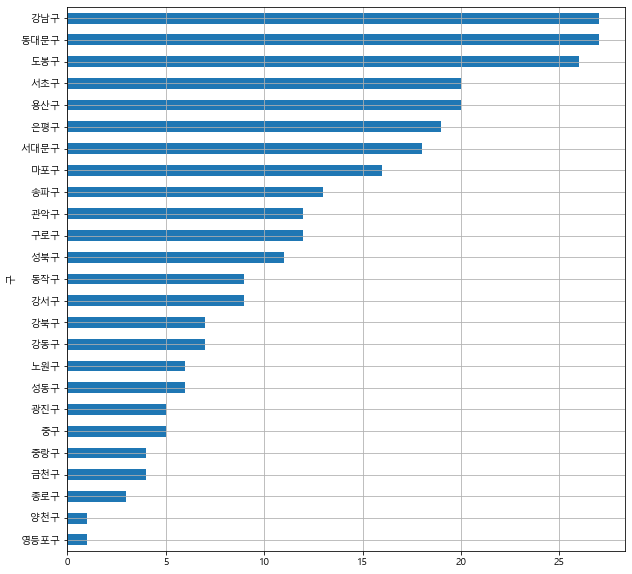

In [20]:
data_result.set_index('구')['도서관개수'].sort_values().plot(kind='barh', grid='True', figsize=(10, 10))

<AxesSubplot:ylabel='구'>

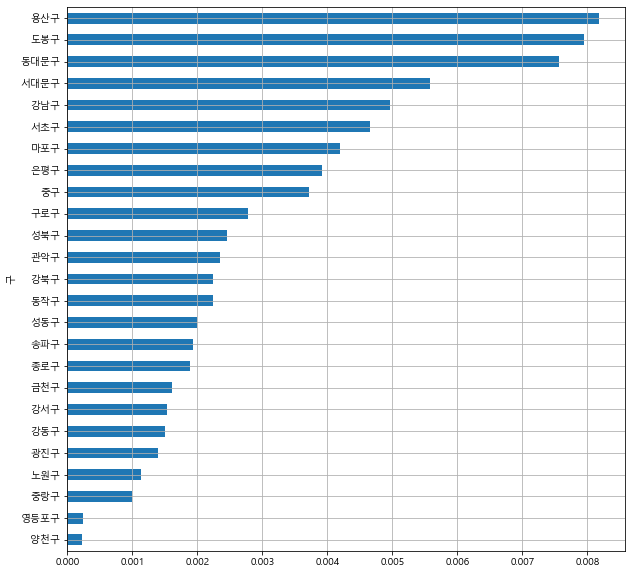

In [21]:
data_result['도서관비율'] = data_result['도서관개수']/data_result['인구수']*100
data_result.set_index('구')['도서관비율'].sort_values().plot(kind='barh', grid='True', figsize=(10, 10))

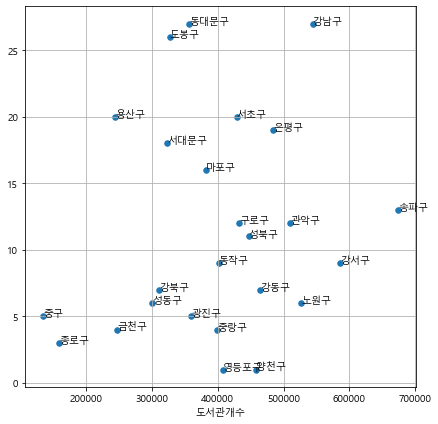

In [22]:
plt.figure(figsize=(7, 7))
plt.scatter(data_result['인구수'], data_result['도서관개수'], s= 30)
for i in data_result['구']:
    plt.text(data_result[data_result['구']==i]['인구수'], data_result[data_result['구']==i]['도서관개수'], i)
plt.xlabel('인구수')
plt.xlabel('도서관개수')
plt.grid()
plt.show()

In [23]:
result = data_result.set_index('구')
result.head()

,인구수,한국인,외국인,고령자,도서관개수,도서관비율
구,,,,,,
종로구,158996,149384,9612,28507,3,0.001887
중구,134635,125240,9395,24495,5,0.003714
용산구,244645,230040,14605,40247,20,0.008175
성동구,300505,293556,6949,45603,6,0.001997
광진구,360109,346682,13427,50560,5,0.001388


In [24]:
import json
geo_str = json.load(open('C:/workspace/02. skorea_municipalities_geo_simple.json', encoding='utf-8'))

In [26]:
map2 = folium.Map(location=[37.5502, 126.982], zoom_start=11, tiles ='Stamen Toner')
map2.choropleth(geo_data=geo_str,
              data=result['도서관비율'],
              columns=[result.index, result['도서관비율']], 
              fill_color='PuBuGn',
              key_on='feature.id')
map2

In [27]:
map = folium.Map(location=[37.5502, 126.982], zoom_start=11,  tiles ='Stamen Toner')
map.choropleth(geo_data=geo_str,
              data=result['도서관개수'],
              columns=[result.index, result['도서관개수']], 
              fill_color='PuBuGn',
              key_on='feature.id')
map